# Proyección del crecimiento de la población

In [2]:
# import functions from modsim

from utils_sim import *

Aquí están, por última vez, los datos de los capítulos anteriores.

In [3]:
from pandas import read_html

filename = 'World_population_estimates.html'
tables = read_html(filename, header=0, index_col=0, decimal='M')
table2 = tables[2]
table2.columns = ['census', 'prb', 'un', 'maddison', 
                  'hyde', 'tanton', 'biraben', 'mj', 
                  'thomlinson', 'durand', 'clark']

In [4]:
un = table2.un / 1e9
census = table2.census / 1e9

Y aquí están las funciones del capítulo anterior.

In [5]:
def plot_estimates():
    census.plot(style=':', label='US Census')
    un.plot(style='--', label='UN DESA')
    decorate(xlabel='Year', 
             ylabel='World population (billions)') 

En el capítulo anterior desarrollamos un modelo cuadrático del crecimiento de la población mundial de 1950 a 2016. Es un modelo simple, pero se ajusta bien a los datos y los mecanismos en los que se basa son plausibles.

En este capítulo usaremos el modelo cuadrático para generar proyecciones de crecimiento futuro y compararemos nuestros resultados con las proyecciones de demógrafos reales.

## Generación de proyecciones

Ejecutemos el modelo cuadrático, extendiendo los resultados hasta 2100, y veamos cómo se comparan nuestras proyecciones con las de los profesionales.

Aquí está de nuevo la función de crecimiento cuadrático.

In [6]:
def growth_func_quad(t, pop, system):
    return system.alpha * pop + system.beta * pop**2

Y aquí están los parámetros del sistema.

In [7]:
t_0 = census.index[0]
p_0 = census[t_0]

system = System(t_0 = t_0,
                p_0 = p_0,
                alpha = 25 / 1000,
                beta = -1.8 / 1000,
                t_end = 2100)

Con `t_end=2100`, podemos generar la proyección llamando a `run_simulation` como de costumbre.

In [8]:
results = run_simulation(system, growth_func_quad)

Aquí están los últimos valores de los resultados.

In [11]:
results.tail()

Time
2096    12.462519
2097    12.494516
2098    12.525875
2099    12.556607
2100    12.586719
Name: Quantity, dtype: float64

Así se ven los resultados.

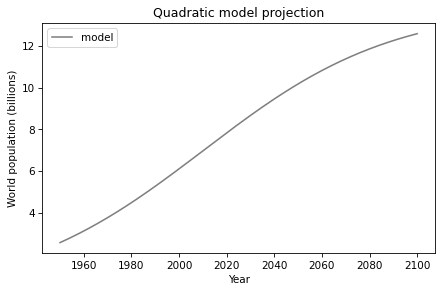

In [12]:
results.plot(color='gray', label='model')
decorar(xlabel='Year', 
         ylabel='World population (billions)',
         title='Quadratic model projection')

Según el modelo, el crecimiento de la población se desacelerará gradualmente después de 2020, acercándose a 12.6 mil millones para 2100.

Estoy usando deliberadamente la palabra *proyección* en lugar de *predicción*, con la siguiente distinción: *predicción* implica algo como “esto es lo que esperamos que suceda, al menos aproximadamente”; *proyección* implica algo como “si este modelo describe bien el sistema, y si nada en el futuro hace que los parámetros del sistema cambien, esto es lo que ocurriría”.

## Comparación de proyecciones

De la misma página de Wikipedia de donde obtuvimos las estimaciones históricas de población, leeremos `table3`, que contiene proyecciones de crecimiento para los próximos 50–100 años, generadas por la Oficina del Censo de EE. UU., la ONU (DESA) y el Population Reference Bureau.

In [13]:
table3 = tables[3]

Los nombres de las columnas son cadenas largas; para mayor comodidad, los reemplazaré por abreviaturas.

In [14]:
table3.columns = ['census', 'prb', 'un']

Aquí están las primeras filas:

In [15]:
table3.head()

,census,prb,un
Year,,,
2016,7.334772e+09,NaN,7.432663e+09
2017,7.412779e+09,NaN,NaN
2018,7.490428e+09,NaN,NaN
2019,7.567403e+09,NaN,NaN
2020,7.643402e+09,NaN,7.758157e+09


Algunos valores son `NaN`, lo que indica datos faltantes, porque algunas organizaciones no publicaron proyecciones para ciertos años. La siguiente función grafica las proyecciones de la ONU (DESA) y la Oficina del Censo de EE. UU. Usa `dropna` para eliminar los valores `NaN` de cada serie antes de graficarla.

In [22]:
def plot_projections(table):
    """Plot world population projections.
    
    table: DataFrame with columns 'un' and 'census'
    """
    census_proj = table.census.dropna() / 1e9
    un_proj = table.un.dropna() / 1e9
    
    census_proj.plot(style=':', label='US Census')
    un_proj.plot(style='--', label='UN DESA')
    
    decorar(xlabel='Year', 
             ylabel='World population (billions)')

Aquí están las proyecciones profesionales comparadas con los resultados del modelo cuadrático.

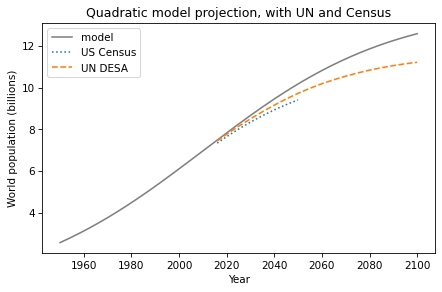

In [23]:
results.plot(color='gray', label='model')
plot_projections(table3)
decorar(title='Quadratic model projection, with UN and Census')

La ONU (DESA) espera que la población mundial alcance los 11 mil millones alrededor de 2100 y luego se estabilice. Las proyecciones de la Oficina del Censo de EE. UU. son un poco más bajas y solo llegan hasta 2050.

## Resumen

En este capítulo usamos el modelo de crecimiento cuadrático para proyectar el crecimiento de la población mundial desde ahora hasta 2100.

Los demógrafos reales esperan un crecimiento más lento que el de nuestro modelo, probablemente porque sus modelos se desagregan por región y país, donde las condiciones son diferentes, y tienen en cuenta el desarrollo económico esperado.

### Ejercicio 1

La tasa neta de crecimiento de la población mundial ha venido disminuyendo durante varias décadas. Esa observación sugiere otra manera de generar proyecciones más realistas: extrapolando los cambios observados en la tasa de crecimiento.

Para calcular las tasas de crecimiento pasadas, usaremos una función llamada `diff`, que calcula la diferencia entre elementos sucesivos en una `Series`. Por ejemplo, estos son los cambios de un año a otro en `census`:

In [ ]:
diff = census.diff()
show(diff.head())

El primer elemento es `NaN` porque no tenemos los datos de 1949, así que no podemos calcular la primera diferencia.

Si dividimos estas diferencias por las poblaciones, el resultado es una estimación de la tasa de crecimiento durante cada año:

In [25]:
alpha = census.diff() / census
alpha.head()

Year
1950         NaN
1951    0.014378
1952    0.015865
1953    0.016883
1954    0.017645
Name: census, dtype: float64

La siguiente función calcula y grafica las tasas de crecimiento para las estimaciones de `census` y `un`:

In [24]:
def plot_alpha():
    alpha_census = census.diff() / census
    alpha_census.plot(style='.', label='US Census')

    alpha_un = un.diff() / un
    alpha_un.plot(style='.', label='UN DESA')

    decorar(xlabel='Year', ylabel='Net growth rate')

Utiliza `style='.'` para graficar cada punto de datos con un pequeño círculo. Y así es como se ve.

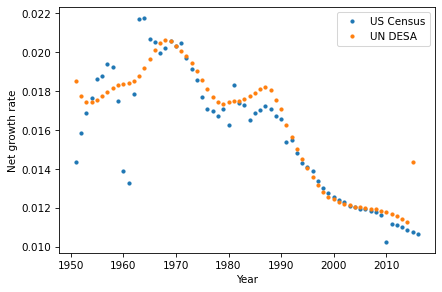

In [26]:
plot_alpha()

Salvo un bache alrededor de 1990, la tasa neta de crecimiento ha venido disminuyendo de manera aproximadamente lineal desde 1970.

Podemos modelar esta disminución ajustando una línea a estos datos y extrapolándola hacia el futuro. Aquí hay una función que toma una marca de tiempo y calcula una línea que se ajusta aproximadamente a las tasas de crecimiento desde 1970.

In [27]:
def alpha_func(t):
    intercept = 0.02
    slope = -0.00021
    return intercept + slope * (t - 1970)

Para ver cómo se ve, crearé un arreglo de marcas de tiempo de 1960 a 2020 y usaré `alpha_func` para calcular las tasas de crecimiento correspondientes.

In [28]:
t_array = np.linspace(1960, 2020, 5)
alpha_array = alpha_func(t_array)

Así es como se ve, comparado con los datos.

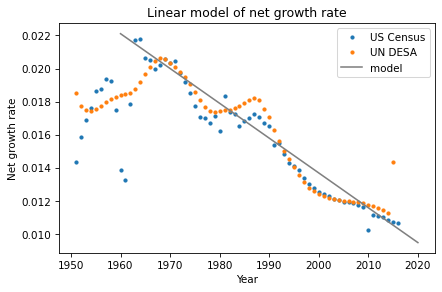

In [29]:
from matplotlib.pyplot import plot

plot_alpha()
plot(t_array, alpha_array, label='model', color='gray')

decorar(ylabel='Net growth rate',
         title='Linear model of net growth rate')

Si no te gustan la `slope` y la `intercept` que elegí, siéntete libre de ajustarlas.

Ahora, como ejercicio, puedes usar esta función para proyectar la población mundial hasta 2100.

1. Crea un objeto `System` que incluya `alpha_func` como un parámetro del sistema.

2. Define una función de crecimiento que use `alpha_func` para calcular la tasa neta de crecimiento en el tiempo `t` dado.

3. Ejecuta una simulación de 1960 a 2100 con tu función de crecimiento y grafica los resultados.

4. Compara tus proyecciones con las de la Oficina del Censo de EE. UU. y la ONU.

In [ ]:
# Solution goes here